# 03 — Model Training & Evaluation

Train and evaluate classifiers on two feature sets x two split strategies:
- **Feature sets**: Correlation-filtered vs PCA-transformed
- **Split strategies**: Random (stratified 80/20) vs Temporal (train pre-2020, test 2020–2021)

Models: Random Forest, Gradient Boosting, SVM, and XGBoost.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from time import time

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

sns.set_style("whitegrid")

## 1. Load Processed Data

In [2]:
def load_split(split_name):
    """Load a processed split (random or temporal) from disk."""
    d = f"../data/processed/{split_name}"
    return {
        "X_train_filt": pd.read_csv(f"{d}/X_train_filtered.csv", index_col=0),
        "X_test_filt": pd.read_csv(f"{d}/X_test_filtered.csv", index_col=0),
        "X_train_pca": pd.read_csv(f"{d}/X_train_pca.csv", index_col=0),
        "X_test_pca": pd.read_csv(f"{d}/X_test_pca.csv", index_col=0),
        "y_train": pd.read_csv(f"{d}/y_train.csv", index_col=0).squeeze(),
        "y_test": pd.read_csv(f"{d}/y_test.csv", index_col=0).squeeze(),
        "le": joblib.load(f"{d}/label_encoder.pkl"),
    }

random_data = load_split("random")
temporal_data = load_split("temporal")

for name, data in [("Random", random_data), ("Temporal", temporal_data)]:
    print(f"\n{name} split:")
    print(f"  Filtered: train={data['X_train_filt'].shape}, test={data['X_test_filt'].shape}")
    print(f"  PCA:      train={data['X_train_pca'].shape}, test={data['X_test_pca'].shape}")
    print(f"  Classes:  {list(data['le'].classes_)}")


Random split:
  Filtered: train=(46534, 38), test=(11634, 38)
  PCA:      train=(46534, 6), test=(11634, 6)
  Classes:  ['Benign', 'Ransomware', 'Spyware', 'Trojan']

Temporal split:
  Filtered: train=(39964, 38), test=(18204, 38)
  PCA:      train=(39964, 7), test=(18204, 7)
  Classes:  ['Benign', 'Ransomware', 'Spyware', 'Trojan']


## 2. Define Models and Training Helper

In [3]:
def make_models():
    """Create fresh model instances."""
    m = {
        "Random Forest": RandomForestClassifier(
            n_estimators=200, random_state=42, n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
        ),
        "SVM (RBF)": SVC(
            kernel="rbf", C=10, gamma="scale", random_state=42, probability=True
        ),
    }
    try:
        from xgboost import XGBClassifier
        m["XGBoost"] = XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            colsample_bytree=0.6, subsample=0.8,
            reg_alpha=1.0, reg_lambda=5.0,
            random_state=42, n_jobs=-1, eval_metric="mlogloss"
        )
    except ImportError:
        print("XGBoost not installed — skipping.")
    return m


def train_and_evaluate(models, X_train, X_test, y_train, y_test, label):
    """Train each model, return results dict."""
    results = {}
    for name, model in models.items():
        print(f"  Training {name}...", end=" ")
        t0 = time()
        model.fit(X_train, y_train)
        train_time = time() - t0

        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"accuracy={acc:.4f}  ({train_time:.1f}s)")

        results[name] = {
            "model": model, "y_pred": y_pred, "accuracy": acc,
            "train_time": train_time, "label": label,
        }
    return results

print(f"Models: {list(make_models().keys())}")

Models: ['Random Forest', 'Gradient Boosting', 'SVM (RBF)', 'XGBoost']


## 3. Train All Combinations

Train each model on 4 combinations: {Random, Temporal} x {Filtered, PCA}.

In [4]:
all_results = {}

for split_name, data in [("Random", random_data), ("Temporal", temporal_data)]:
    for feat_name, feat_key in [("Filtered", "filt"), ("PCA", "pca")]:
        combo = f"{split_name} / {feat_name}"
        print(f"\n{'='*50}")
        print(f"{combo} (train={data[f'X_train_{feat_key}'].shape})")
        print(f"{'='*50}")

        results = train_and_evaluate(
            make_models(),
            data[f"X_train_{feat_key}"], data[f"X_test_{feat_key}"],
            data["y_train"], data["y_test"],
            label=combo,
        )

        for model_name, res in results.items():
            res["split"] = split_name
            res["feature_set"] = feat_name
            res["le"] = data["le"]
            all_results[f"{model_name} ({combo})"] = res

print(f"\nTotal experiments: {len(all_results)}")


Random / Filtered (train=(46534, 38))
  Training Random Forest... accuracy=0.8714  (3.0s)
  Training Gradient Boosting... accuracy=0.8681  (240.0s)
  Training SVM (RBF)... accuracy=0.7670  (262.9s)
  Training XGBoost... accuracy=0.8615  (5.4s)

Random / PCA (train=(46534, 6))
  Training Random Forest... accuracy=0.8176  (3.0s)
  Training Gradient Boosting... accuracy=0.7918  (135.1s)
  Training SVM (RBF)... accuracy=0.7240  (146.4s)
  Training XGBoost... accuracy=0.7807  (8.5s)

Temporal / Filtered (train=(39964, 38))
  Training Random Forest... accuracy=0.6864  (1.8s)
  Training Gradient Boosting... accuracy=0.6808  (205.7s)
  Training SVM (RBF)... accuracy=0.5415  (76.8s)
  Training XGBoost... accuracy=0.6941  (5.9s)

Temporal / PCA (train=(39964, 7))
  Training Random Forest... accuracy=0.6359  (2.3s)
  Training Gradient Boosting... accuracy=0.5771  (130.6s)
  Training SVM (RBF)... accuracy=0.4778  (81.1s)
  Training XGBoost... accuracy=0.5834  (5.9s)

Total experiments: 16


## 4. Classification Reports

In [5]:
for name, res in all_results.items():
    split_data = random_data if res["split"] == "Random" else temporal_data
    print(f"\n{'='*60}")
    print(f"{name}  —  Accuracy: {res['accuracy']:.4f}")
    print(f"{'='*60}")
    print(classification_report(
        split_data["y_test"], res["y_pred"], target_names=res["le"].classes_
    ))


Random Forest (Random / Filtered)  —  Accuracy: 0.8714
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.72      0.72      0.72      1958
     Spyware       0.78      0.79      0.78      2004
      Trojan       0.72      0.71      0.72      1812

    accuracy                           0.87     11634
   macro avg       0.80      0.80      0.80     11634
weighted avg       0.87      0.87      0.87     11634


Gradient Boosting (Random / Filtered)  —  Accuracy: 0.8681
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.72      0.72      0.72      1958
     Spyware       0.77      0.79      0.78      2004
      Trojan       0.71      0.69      0.70      1812

    accuracy                           0.87     11634
   macro avg       0.80      0.80      0.80     11634
weighted avg       0.87      0.87      0.87     11634


SVM (RBF) (Ra

## 5. Accuracy Comparison — Random vs Temporal Split

In [6]:
summary = pd.DataFrame([
    {"Experiment": name, "Model": name.split(" (")[0],
     "Split": res["split"], "Feature Set": res["feature_set"],
     "Accuracy": res["accuracy"], "Train Time (s)": round(res["train_time"], 1)}
    for name, res in all_results.items()
]).sort_values("Accuracy", ascending=False).reset_index(drop=True)

summary

,Experiment,Model,Split,Feature Set,Accuracy,Train Time (s)
0,Random Forest (Random / Filtered),Random Forest,Random,Filtered,0.871411,3.0
1,Gradient Boosting (Random / Filtered),Gradient Boosting,Random,Filtered,0.868059,240.0
2,XGBoost (Random / Filtered),XGBoost,Random,Filtered,0.861527,5.4
3,Random Forest (Random / PCA),Random Forest,Random,PCA,0.817604,3.0
4,Gradient Boosting (Random / PCA),Gradient Boosting,Random,PCA,0.791817,135.1
5,XGBoost (Random / PCA),XGBoost,Random,PCA,0.780729,8.5
6,SVM (RBF) (Random / Filtered),SVM,Random,Filtered,0.766976,262.9
7,SVM (RBF) (Random / PCA),SVM,Random,PCA,0.723999,146.4
8,XGBoost (Temporal / Filtered),XGBoost,Temporal,Filtered,0.694078,5.9
9,Random Forest (Temporal / Filtered),Random Forest,Temporal,Filtered,0.686388,1.8


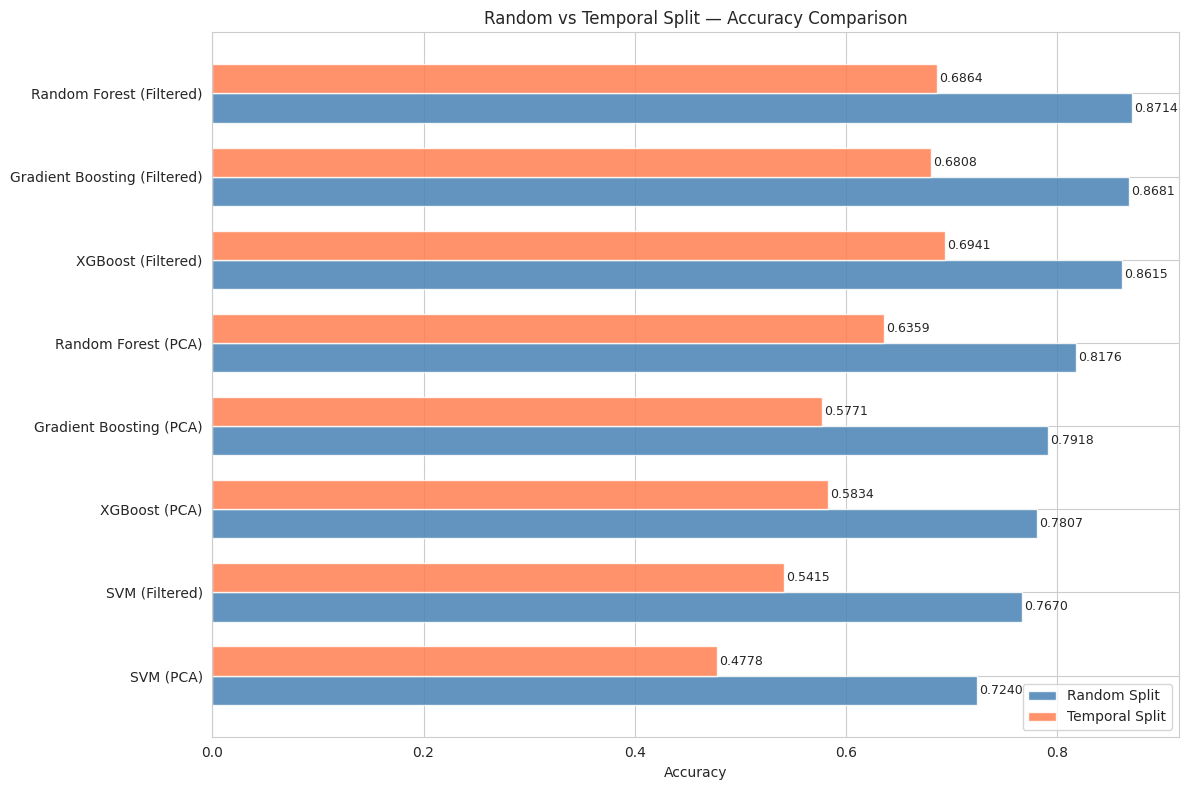


Accuracy drop (Random → Temporal):
  SVM (PCA): 0.7240 → 0.4778  (Δ = +0.2462)
  SVM (Filtered): 0.7670 → 0.5415  (Δ = +0.2254)
  XGBoost (PCA): 0.7807 → 0.5834  (Δ = +0.1973)
  Gradient Boosting (PCA): 0.7918 → 0.5771  (Δ = +0.2147)
  Random Forest (PCA): 0.8176 → 0.6359  (Δ = +0.1817)
  XGBoost (Filtered): 0.8615 → 0.6941  (Δ = +0.1674)
  Gradient Boosting (Filtered): 0.8681 → 0.6808  (Δ = +0.1873)
  Random Forest (Filtered): 0.8714 → 0.6864  (Δ = +0.1850)


In [7]:
# Side-by-side comparison: Random vs Temporal for each model+feature combo
from matplotlib.patches import Patch

pivot = summary.pivot_table(index=["Model", "Feature Set"], columns="Split", values="Accuracy")
pivot = pivot.sort_values("Random", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = range(len(pivot))
bar_height = 0.35

bars1 = ax.barh([y - bar_height/2 for y in y_pos], pivot["Random"], bar_height,
                label="Random Split", color="steelblue", alpha=0.85)
bars2 = ax.barh([y + bar_height/2 for y in y_pos], pivot["Temporal"], bar_height,
                label="Temporal Split", color="coral", alpha=0.85)

ax.set_yticks(list(y_pos))
ax.set_yticklabels([f"{m} ({f})" for m, f in pivot.index])
ax.set_xlabel("Accuracy")
ax.set_title("Random vs Temporal Split — Accuracy Comparison")
ax.legend(loc="lower right")

for bars in [bars1, bars2]:
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{width:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# Show the accuracy drop
print("\nAccuracy drop (Random → Temporal):")
for (model, feat), row in pivot.iterrows():
    drop = row["Random"] - row["Temporal"]
    print(f"  {model} ({feat}): {row['Random']:.4f} → {row['Temporal']:.4f}  (Δ = {drop:+.4f})")

## 6. Confusion Matrices — Best Model per Split

Compare the best model's confusion matrix on random vs temporal test sets.


Random Split — Random Forest (acc=0.8714)
Confusion Matrix (rows=true, cols=predicted):
            Benign  Ransomware  Spyware  Trojan
Benign        5859           0        1       0
Ransomware       0        1402      267     289
Spyware          0         211     1582     211
Trojan           0         338      179    1295

Temporal Split — XGBoost (acc=0.6941)
Confusion Matrix (rows=true, cols=predicted):
            Benign  Ransomware  Spyware  Trojan
Benign        5860           0        0       0
Ransomware       0        2474     1228    1989
Spyware          5         575     3616    1142
Trojan           0         447      183     685


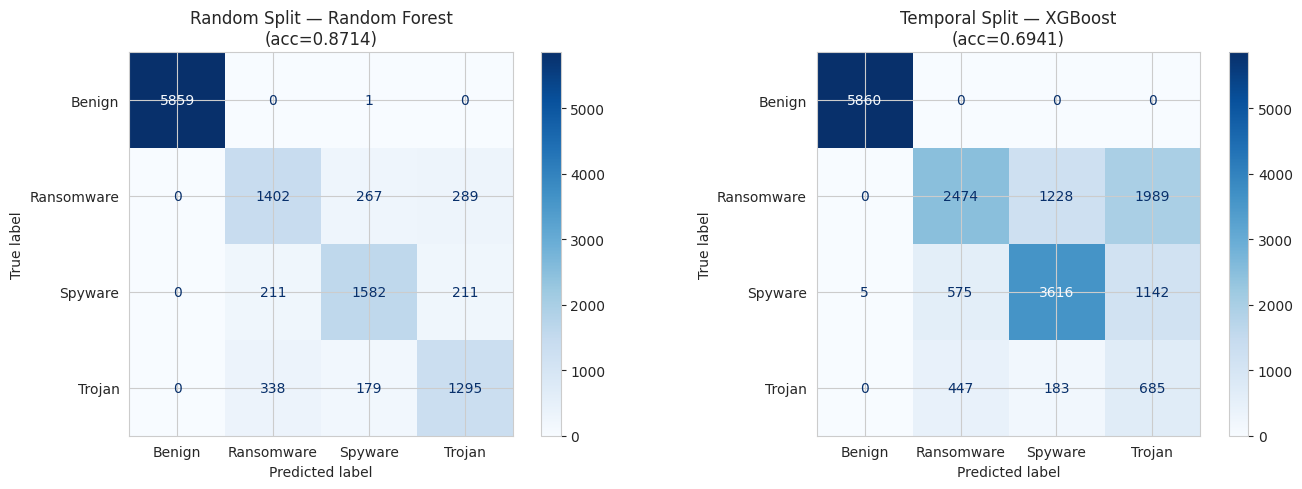

In [8]:
# Best model per split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split_name, data in zip(axes, ["Random", "Temporal"], [random_data, temporal_data]):
    # Find best result for this split
    split_results = {k: v for k, v in all_results.items() if v["split"] == split_name}
    best_name, best_res = max(split_results.items(), key=lambda x: x[1]["accuracy"])

    cm = confusion_matrix(data["y_test"], best_res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=best_res["le"].classes_)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"{split_name} Split — {best_name.split(' (')[0]}\n(acc={best_res['accuracy']:.4f})")

    # Text output
    print(f"\n{split_name} Split — {best_name.split(' (')[0]} (acc={best_res['accuracy']:.4f})")
    print(f"Confusion Matrix (rows=true, cols=predicted):")
    cm_df = pd.DataFrame(cm, index=best_res["le"].classes_, columns=best_res["le"].classes_)
    print(cm_df.to_string())

plt.tight_layout()
plt.show()

## 7. ROC Curves (One-vs-Rest) — Random vs Temporal

Plot per-class ROC curves for the best model from each split side by side.


Random Split — Random Forest (ROC AUC per class):
  Benign: AUC = 1.0000
  Ransomware: AUC = 0.9529
  Spyware: AUC = 0.9688
  Trojan: AUC = 0.9512

Temporal Split — XGBoost (ROC AUC per class):
  Benign: AUC = 1.0000
  Ransomware: AUC = 0.8612
  Spyware: AUC = 0.9028
  Trojan: AUC = 0.8054


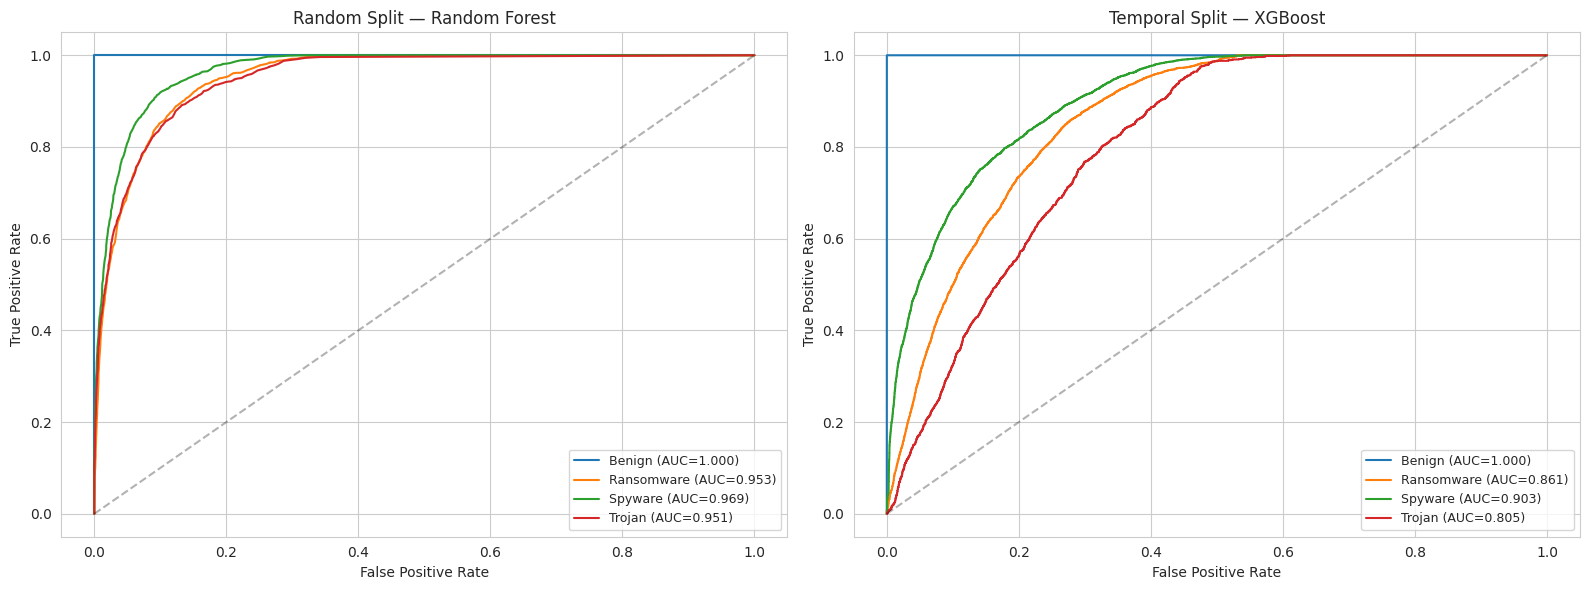

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, split_name, data in zip(axes, ["Random", "Temporal"], [random_data, temporal_data]):
    # Best model for this split (filtered features for probability support)
    split_filt = {k: v for k, v in all_results.items()
                  if v["split"] == split_name and v["feature_set"] == "Filtered"}
    best_name, best_res = max(split_filt.items(), key=lambda x: x[1]["accuracy"])
    best_model = best_res["model"]
    le = best_res["le"]

    X_test_best = data["X_test_filt"]

    if hasattr(best_model, "predict_proba"):
        y_score = best_model.predict_proba(X_test_best)
    else:
        y_score = best_model.decision_function(X_test_best)

    n_classes = len(le.classes_)
    y_test_bin = label_binarize(data["y_test"], classes=range(n_classes))

    print(f"\n{split_name} Split — {best_name.split(' (')[0]} (ROC AUC per class):")
    for i, class_name in enumerate(le.classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.3f})")
        print(f"  {class_name}: AUC = {roc_auc:.4f}")

    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{split_name} Split — {best_name.split(' (')[0]}")
    ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

## 8. Feature Importance — Random vs Temporal

Compare which features matter most when the model is trained on historical data vs random data.

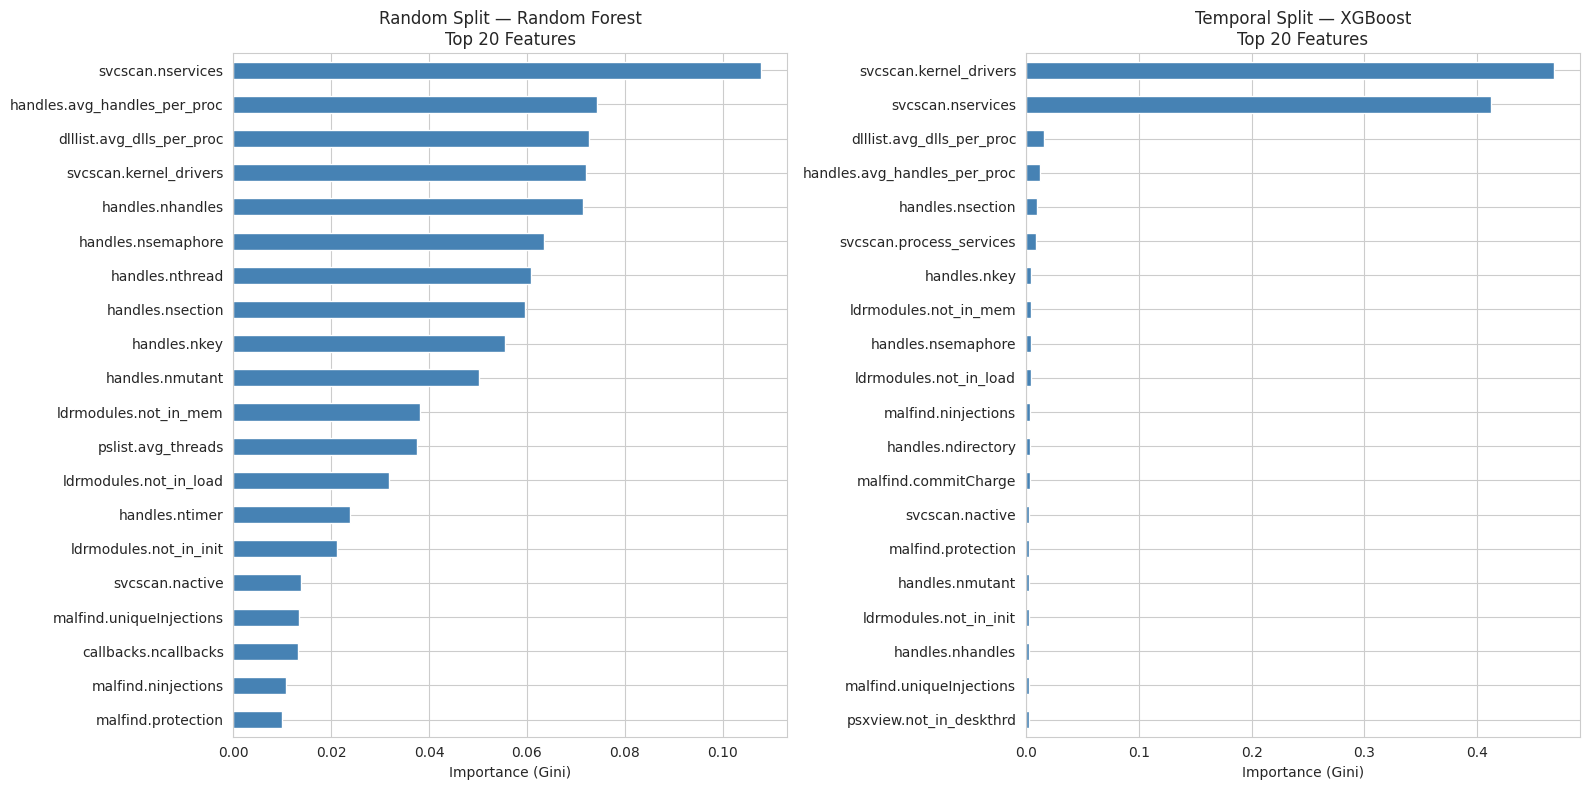

In [13]:
# Best tree-based model (Filtered features) from each split
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, split_name, data in zip(axes, ["Random", "Temporal"], [random_data, temporal_data]):
    # Find best tree-based filtered model for this split
    tree_results = {k: v for k, v in all_results.items()
                    if v["split"] == split_name and v["feature_set"] == "Filtered"
                    and hasattr(v["model"], "feature_importances_")}

    if not tree_results:
        ax.text(0.5, 0.5, "No tree models", ha="center", va="center")
        continue

    best_name, best_res = max(tree_results.items(), key=lambda x: x[1]["accuracy"])
    importances = pd.Series(
        best_res["model"].feature_importances_, index=data["X_train_filt"].columns
    )
    top20 = importances.nlargest(20)
    top20.sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_title(f"{split_name} Split — {best_name.split(' (')[0]}\nTop 20 Features")
    ax.set_xlabel("Importance (Gini)")

plt.tight_layout()
plt.show()

### 8a. Investigating svcscan Feature Importance

The temporal model relies heavily on `svcscan.nservices` and `svcscan.shared_process_services`. Are these features capturing actual malware behavior, or just OS/configuration drift over time?

svcscan features: ['svcscan.nservices', 'svcscan.kernel_drivers', 'svcscan.fs_drivers', 'svcscan.process_services', 'svcscan.shared_process_services', 'svcscan.interactive_process_services', 'svcscan.nactive']


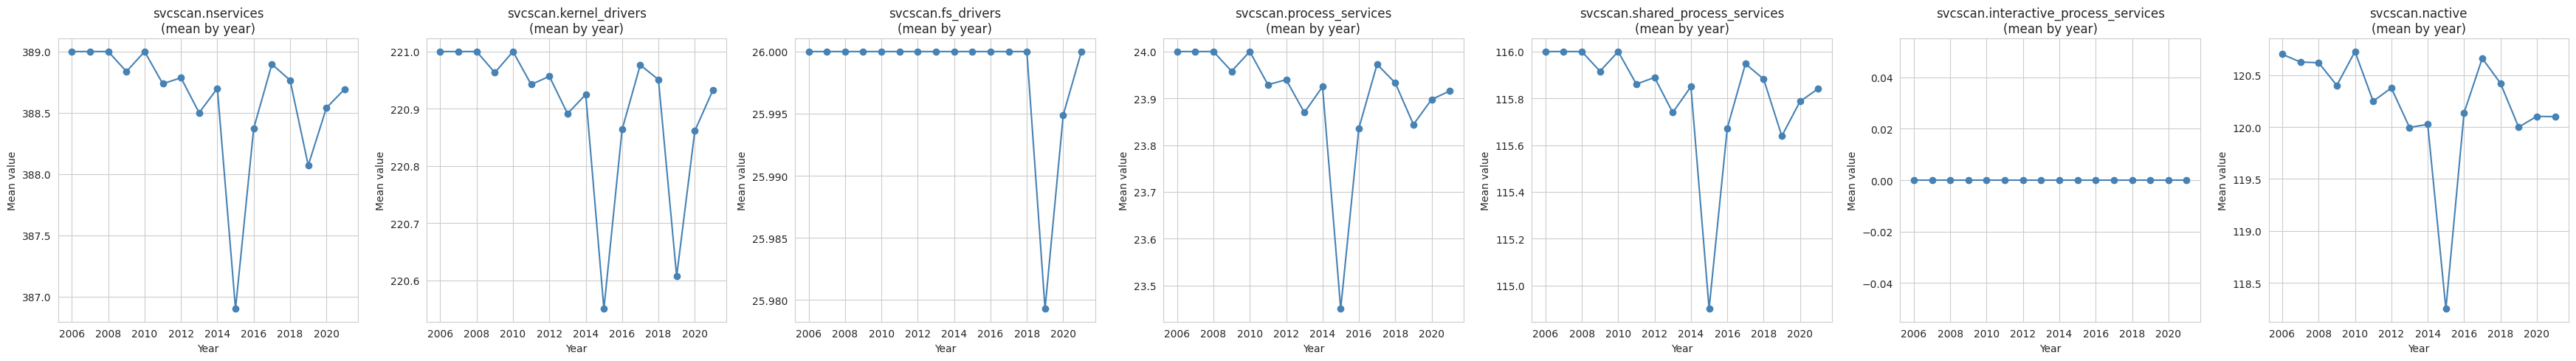


Correlation with Year (malware samples only):
  svcscan.nservices: r = -0.0234
  svcscan.kernel_drivers: r = -0.0178
  svcscan.fs_drivers: r = -0.0111
  svcscan.process_services: r = -0.0353
  svcscan.shared_process_services: r = -0.0283
  svcscan.interactive_process_services: r = nan
  svcscan.nactive: r = -0.0386


/home/m33d/development/memhuntr/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/m33d/development/memhuntr/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [14]:
# Load raw data to get Year + svcscan features
df_benign = pd.read_csv("../data/raw/All Benign Samples-combined.csv")
df_malware = pd.read_csv("../data/raw/All Malware Samples-Combined2006-2021.csv")
df_raw = pd.concat([df_benign, df_malware], ignore_index=True)
df_raw.columns = df_raw.columns.str.strip()

# Only malware samples have Year
df_malware_only = df_raw[df_raw["Year"].notna()].copy()
df_malware_only["Year"] = df_malware_only["Year"].astype(int)

svcscan_cols = [c for c in df_raw.columns if c.startswith("svcscan")]
print(f"svcscan features: {svcscan_cols}")

# Plot svcscan features by year
fig, axes = plt.subplots(1, len(svcscan_cols), figsize=(5 * len(svcscan_cols), 5))
if len(svcscan_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, svcscan_cols):
    yearly = df_malware_only.groupby("Year")[col].mean()
    yearly.plot(ax=ax, marker="o", color="steelblue")
    ax.set_title(f"{col}\n(mean by year)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean value")

plt.tight_layout()
plt.show()

# Pearson correlation of svcscan features with Year
print("\nCorrelation with Year (malware samples only):")
for col in svcscan_cols:
    r = df_malware_only["Year"].corr(df_malware_only[col])
    print(f"  {col}: r = {r:.4f}")

## 9. Two-Stage Classifier — Binary then Subtype

**Stage 1:** Benign vs Malware (binary) — already near-perfect.
**Stage 2:** Malware subtype classification — only runs on samples predicted as malware.

This isolates the hard problem (subtype classification) from the easy one (malware detection).

In [15]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

two_stage_results = {}

for split_name, data in [("Random", random_data), ("Temporal", temporal_data)]:
    print(f"\n{'='*60}")
    print(f"Two-Stage Classifier — {split_name} Split")
    print(f"{'='*60}")

    le = data["le"]
    X_train = data["X_train_filt"]
    X_test = data["X_test_filt"]
    y_train = data["y_train"]
    y_test = data["y_test"]

    # Map encoded labels back to class names
    class_names = le.classes_
    y_train_names = pd.Series(class_names[y_train.values], index=y_train.index)
    y_test_names = pd.Series(class_names[y_test.values], index=y_test.index)

    # --- Stage 1: Binary (Benign=0, Malware=1) ---
    y_train_binary = (y_train_names != "Benign").astype(int)
    y_test_binary = (y_test_names != "Benign").astype(int)

    stage1 = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        colsample_bytree=0.6, subsample=0.8,
        reg_alpha=1.0, reg_lambda=5.0,
        random_state=42, n_jobs=-1, eval_metric="logloss"
    )
    t0 = time()
    stage1.fit(X_train, y_train_binary)
    stage1_time = time() - t0

    y_pred_binary = stage1.predict(X_test)
    stage1_acc = accuracy_score(y_test_binary, y_pred_binary)
    print(f"\n  Stage 1 (Benign vs Malware): accuracy={stage1_acc:.4f}  ({stage1_time:.1f}s)")

    # --- Stage 2: Malware subtype (only malware samples, class-weighted) ---
    malware_train_mask = y_train_names != "Benign"
    X_train_mal = X_train[malware_train_mask]
    y_train_mal = y_train_names[malware_train_mask]

    le_mal = LabelEncoder()
    y_train_mal_enc = le_mal.fit_transform(y_train_mal)

    # Compute sample weights to balance classes
    sample_weights = compute_sample_weight("balanced", y_train_mal_enc)

    # Show class distribution and weights
    print(f"\n  Stage 2 class distribution (train):")
    for cls_name in le_mal.classes_:
        count = (y_train_mal == cls_name).sum()
        weight = sample_weights[y_train_mal_enc == le_mal.transform([cls_name])[0]][0]
        print(f"    {cls_name}: {count} samples (weight={weight:.2f})")

    stage2 = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        colsample_bytree=0.6, subsample=0.8,
        reg_alpha=1.0, reg_lambda=5.0,
        random_state=42, n_jobs=-1, eval_metric="mlogloss"
    )
    t0 = time()
    stage2.fit(X_train_mal, y_train_mal_enc, sample_weight=sample_weights)
    stage2_time = time() - t0

    # --- Combine: predict on test set ---
    y_pred_combined = np.array(["Benign"] * len(X_test), dtype=object)
    pred_binary_mask = y_pred_binary == 1

    if pred_binary_mask.sum() > 0:
        X_test_mal = X_test[pred_binary_mask]
        subtype_preds = stage2.predict(X_test_mal)
        y_pred_combined[pred_binary_mask] = le_mal.inverse_transform(subtype_preds)

    # Overall accuracy
    combined_acc = accuracy_score(y_test_names, y_pred_combined)
    print(f"\n  Stage 2 (Subtype, weighted):  ({stage2_time:.1f}s)")
    print(f"  Combined accuracy:           {combined_acc:.4f}")

    # Classification report
    print(f"\n{classification_report(y_test_names, y_pred_combined)}")

    # Confusion matrix
    cm = confusion_matrix(y_test_names, y_pred_combined, labels=class_names)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    print("Confusion Matrix (rows=true, cols=predicted):")
    print(cm_df.to_string())

    two_stage_results[split_name] = {
        "stage1": stage1, "stage2": stage2,
        "le_mal": le_mal, "le": le,
        "y_pred": y_pred_combined,
        "accuracy": combined_acc,
        "y_test_names": y_test_names,
    }


Two-Stage Classifier — Random Split

  Stage 1 (Benign vs Malware): accuracy=0.9999  (3.4s)

  Stage 2 class distribution (train):
    Ransomware: 7833 samples (weight=0.98)
    Spyware: 8016 samples (weight=0.96)
    Trojan: 7247 samples (weight=1.06)

  Stage 2 (Subtype, weighted):  (3.1s)
  Combined accuracy:           0.8644

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.72      0.69      0.70      1958
     Spyware       0.77      0.78      0.77      2004
      Trojan       0.69      0.70      0.70      1812

    accuracy                           0.86     11634
   macro avg       0.79      0.79      0.79     11634
weighted avg       0.86      0.86      0.86     11634

Confusion Matrix (rows=true, cols=predicted):
            Benign  Ransomware  Spyware  Trojan
Benign        5859           0        1       0
Ransomware       0        1359      296     303
Spyware          0         181     1568   

Single-stage vs Two-stage (class-weighted) comparison:

Split        Single-stage    Two-stage       Delta     
----------------------------------------------------
Random       0.8615          0.8644          +0.0028
Temporal     0.6941          0.7288          +0.0347


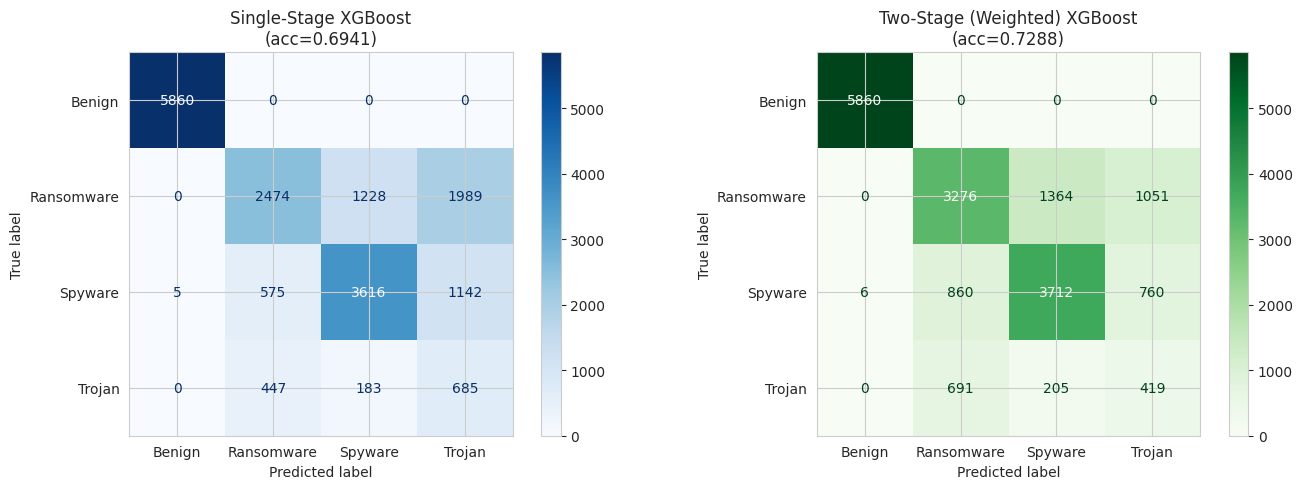

In [16]:
# Compare: single-stage XGBoost vs two-stage (class-weighted)
print("Single-stage vs Two-stage (class-weighted) comparison:\n")
print(f"{'Split':<12} {'Single-stage':<15} {'Two-stage':<15} {'Delta':<10}")
print("-" * 52)

for split_name in ["Random", "Temporal"]:
    single = [v for k, v in all_results.items()
              if v["split"] == split_name and "XGBoost" in k and v["feature_set"] == "Filtered"][0]
    two = two_stage_results[split_name]
    delta = two["accuracy"] - single["accuracy"]
    print(f"{split_name:<12} {single['accuracy']:<15.4f} {two['accuracy']:<15.4f} {delta:+.4f}")

# Side-by-side confusion matrices for temporal split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Single-stage
single_res = [v for k, v in all_results.items()
              if v["split"] == "Temporal" and "XGBoost" in k and v["feature_set"] == "Filtered"][0]
cm1 = confusion_matrix(temporal_data["y_test"], single_res["y_pred"])
ConfusionMatrixDisplay(cm1, display_labels=single_res["le"].classes_).plot(ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title(f"Single-Stage XGBoost\n(acc={single_res['accuracy']:.4f})")

# Two-stage
two_res = two_stage_results["Temporal"]
cm2 = confusion_matrix(two_res["y_test_names"], two_res["y_pred"], labels=two_res["le"].classes_)
ConfusionMatrixDisplay(cm2, display_labels=two_res["le"].classes_).plot(ax=axes[1], cmap="Greens", values_format="d")
axes[1].set_title(f"Two-Stage (Weighted) XGBoost\n(acc={two_res['accuracy']:.4f})")

plt.tight_layout()
plt.show()

## 10. Save Best Models

In [17]:
# Save best single-stage model from each split
for split_name in ["Random", "Temporal"]:
    split_results = {k: v for k, v in all_results.items() if v["split"] == split_name}
    best_name, best_res = max(split_results.items(), key=lambda x: x[1]["accuracy"])
    out_dir = f"../data/processed/{split_name.lower()}"
    joblib.dump(best_res["model"], f"{out_dir}/best_model.pkl")
    print(f"{split_name}: {best_name.split(' (')[0]} (acc={best_res['accuracy']:.4f}) → {out_dir}/best_model.pkl")

# Save two-stage models (best overall)
for split_name, res in two_stage_results.items():
    out_dir = f"../data/processed/{split_name.lower()}"
    joblib.dump(res["stage1"], f"{out_dir}/two_stage_stage1.pkl")
    joblib.dump(res["stage2"], f"{out_dir}/two_stage_stage2.pkl")
    joblib.dump(res["le_mal"], f"{out_dir}/two_stage_le_mal.pkl")
    print(f"{split_name}: Two-stage (acc={res['accuracy']:.4f}) → {out_dir}/two_stage_*.pkl")

# Save full comparison table
summary.to_csv("../data/processed/model_comparison.csv", index=False)
print(f"\nComparison table → ../data/processed/model_comparison.csv")

Random: Random Forest (acc=0.8714) → ../data/processed/random/best_model.pkl
Temporal: XGBoost (acc=0.6941) → ../data/processed/temporal/best_model.pkl
Random: Two-stage (acc=0.8644) → ../data/processed/random/two_stage_*.pkl
Temporal: Two-stage (acc=0.7288) → ../data/processed/temporal/two_stage_*.pkl

Comparison table → ../data/processed/model_comparison.csv
